# Visualizing Spectra and Plotting 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nrevyw/wyvern-public-resources/blob/main/tutorial-notebooks/visualizing-spectra/visualizing_spectra.ipynb)

This notebook details how to produce 2-D scatter plots and spectral curve plots with Wyvern data in Python. These plots can be used to understand the various materials, objects, and species of vegetation that are present in an image.

More details can be found on our Knowledge Centre at the following link:

https://knowledge.wyvern.space/#/using_wyvern_data/python/python.md

## Getting started
- **Google Colab (easiest):** open this notebook using the "Open in Colab" badge above, then run the cells top to bottom.
- **Local Jupyter:** run this notebook in your tool of choice (Jupyter Lab, Visual Studio Code, etc). The Setup cell below installs everything it needs, no environment to build ahead of time.

## Image we're using
We're using the image also used in `loading_data.ipynb`. Check out the renderings of the image there, or
on the [Wyvern Open Data Catalog](https://opendata.wyvern.space/#/year/2024/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json)!

## Spectral Plots
These plots show surface reflectance of individual pixels across the electromagnetic spectrum that Wyvern's imagery senses. The spectral curve can be used to visually identify the pixel, and can be used by machine learning (and other methods!) to classify the spectral curve as a particular material/species of vegetation. We will dive into classification methods in another tutorial.

## Scatter Plots
2-dimensional scatter plots showcase the distribution of pixels across different bands. This can be used to group spectrally similar pixels, or identify where a particular pixel lies on the plot.


This notebook is self-contained and runs top to bottom in [Google Colab](https://colab.research.google.com/) or any local Jupyter install. Run the cell below first to install the packages it needs, then continue through the notebook. Nothing else needs to be set up.

In [1]:
# Install the packages this notebook needs.
%pip install -q numpy matplotlib requests rasterio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# First, let's import our required packages
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle

## Download the Tutorial Files

Let's download the GeoTIFF and its STAC JSON metadata!

Run the cell below to download these files. Once the download is complete, they'll appear in the same folder as your notebook!

In [3]:
import requests
from pathlib import Path

IMAGE_URL = "https://wyvern-data.com/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.tiff"
JSON_URL = "https://wyvern-odp.com/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json"

IMAGE_PATH = Path("wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.tiff")
JSON_PATH = Path("wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json")

downloads = [
    (IMAGE_URL, IMAGE_PATH),
    (JSON_URL, JSON_PATH),
]

for url, path in downloads:
    if path.exists():
        print(f"{path.name} File already here! Skipping download.")
    else:
        print(f"Downloading {path.name}...")
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()
        path.write_bytes(response.content)

print("Downloads complete!")

wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.tiff File already here! Skipping download.
wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json File already here! Skipping download.
Downloads complete!


### Loading the Data

We'll start by reading the scale factor from the metadata JSON file we downloaded earlier. Wyvern's L2A products represent surface reflectance, but the values are stored as scaled 16-bit integers to reduce file size.

In [4]:
# Open the JSON metadata file and extract the scale factor
with open(JSON_PATH) as json_file:
    metadata = json.load(json_file)

# The scale factor converts stored uint16 reflectance values into their floating-point representation
scale_factor = metadata["assets"]["Cloud optimized GeoTiff"]["raster:bands"][0]["scale"]

# if you don't have the JSON file, you can hardcode the scale factor:
# scale_factor = 0.0001

print(f"Scale factor: {scale_factor}")

Scale factor: 0.0001


Now let's open the GeoTIFF using [rasterio](https://rasterio.readthedocs.io/en/stable/api/index.html). We'll replace any nodata pixels with `np.nan` so they are excluded from our calculations, then apply the scale factor to recover the floating-point reflectance values.

In [5]:
with rasterio.open(IMAGE_PATH) as image_file:
    # Convert to float so we can use np.nan and decimal values
    image_arr = image_file.read().astype(np.float32)
    nodata = image_file.nodata
    band_descriptions = image_file.descriptions

# Replace nodata pixels with NaN so they are excluded from calculations
if nodata is not None:
    image_arr[image_arr == nodata] = np.nan

# Apply the scale factor to recover floating-point reflectance values
image_arr *= scale_factor

print(f"Image shape: {image_arr.shape}")
print(f"Image bands: {', '.join(band_descriptions)}")

Image shape: (23, 7827, 5618)
Image bands: Band_503, Band_510, Band_519, Band_535, Band_549, Band_570, Band_584, Band_600, Band_614, Band_635, Band_649, Band_660, Band_669, Band_679, Band_690, Band_699, Band_711, Band_722, Band_734, Band_750, Band_764, Band_782, Band_799


## Building the Wavelength Map

We'll build a map from wavelength to band index using the `eo:bands` metadata, and a small helper to select bands by wavelength.

In [6]:
with open(JSON_PATH) as json_file:
    metadata = json.load(json_file)

wavelength_map = {}
for i, band in enumerate(metadata["assets"]["Cloud optimized GeoTiff"]["eo:bands"]):
    wavelength = round(band["center_wavelength"] * 1000)  # convert from μm to nm
    wavelength_map[wavelength] = i

print(wavelength_map)

{503: 0, 510: 1, 519: 2, 535: 3, 549: 4, 570: 5, 584: 6, 600: 7, 614: 8, 635: 9, 649: 10, 660: 11, 669: 12, 679: 13, 690: 14, 699: 15, 711: 16, 722: 17, 734: 18, 750: 19, 764: 20, 782: 21, 799: 22}


### Selecting Bands by Wavelength

In [7]:
def get_band(wavelength_nm: int) -> np.ndarray:
    """
    Returns the image band closest to the requested wavelength.

    Args:
        wavelength_nm: Target wavelength in nanometres.

    Returns:
        A 2D array containing reflectance values for the closest available wavelength band.
    """
    available_wavelengths = list(wavelength_map.keys())
    closest_wavelength = min(
        available_wavelengths, key=lambda w: abs(w - wavelength_nm)
    )
    print(f"Requested {wavelength_nm}nm -- using {closest_wavelength}nm")
    return image_arr[wavelength_map[closest_wavelength]]

# Spectral Curve Plot

Requested 650nm -- using 649nm
Requested 550nm -- using 549nm
Requested 503nm -- using 503nm


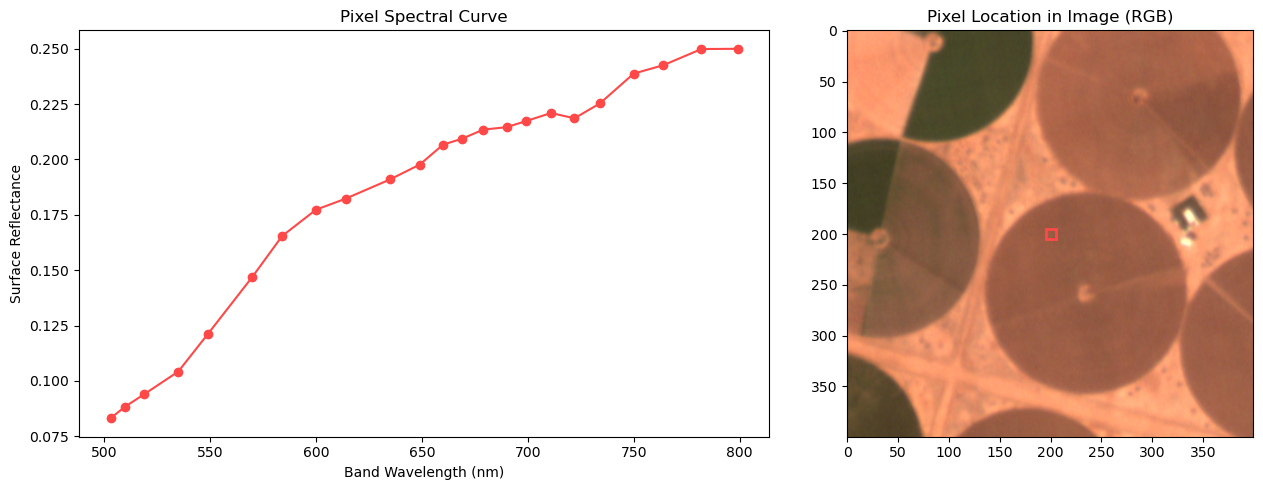

In [8]:
# To plot a spectral curve, we first need to pick a pixel in the image to plot!
PIXEL_ROW, PIXEL_COL = 1600, 1900  # Point on image to plot, feel free to change!

pixel_spectra = image_arr[:, PIXEL_ROW, PIXEL_COL]  # Grabbing pixel from image array

# Order our wavelengths by band index so they line up with pixel_spectra for the line plot
idx_to_wavelength = {i: wavelength for wavelength, i in wavelength_map.items()}
band_wavelengths = [idx_to_wavelength[i] for i in range(image_arr.shape[0])]

# Subplots allows us to plot two things at once! Neat!
fig, axs = plt.subplots(1, 2, figsize=(13, 5), width_ratios=[1.5, 1])

# First, plotting the spectra as a line chart
axs[0].plot(band_wavelengths, pixel_spectra, marker="o", color="#ff4848")
axs[0].set_title("Pixel Spectral Curve")
axs[0].set_xlabel("Band Wavelength (nm)")
axs[0].set_ylabel("Surface Reflectance")

# Secondly, plotting a buffered area around our pixel to visualize what we're looking at!
rgb_crop = np.dstack(
    [
        get_band(650)[
            PIXEL_ROW - 200 : PIXEL_ROW + 200, PIXEL_COL - 200 : PIXEL_COL + 200
        ],
        get_band(550)[
            PIXEL_ROW - 200 : PIXEL_ROW + 200, PIXEL_COL - 200 : PIXEL_COL + 200
        ],
        get_band(503)[
            PIXEL_ROW - 200 : PIXEL_ROW + 200, PIXEL_COL - 200 : PIXEL_COL + 200
        ],
    ]
).astype(np.float32)

brightness_factor = 3  # Bring up the brightness a touch so we have a better visual
rgb_crop_bright = rgb_crop * brightness_factor
rgb_crop_bright = np.clip(rgb_crop_bright, 0, 1)  # keep values within 0-1

axs[1].imshow(rgb_crop_bright)

# We can also add a red box around the pixel we are looking at in the line chart!
pixel_rect = Rectangle(
    (195, 195), 10, 10, linewidth=2, edgecolor="#ff4848", facecolor="none"
)
axs[1].add_patch(pixel_rect)
axs[1].set_title("Pixel Location in Image (RGB)")

plt.tight_layout()
plt.show()

## Spectral Curve Discussion
Because this is L2A surface reflectance data, atmospheric effects like gas absorption and Rayleigh scattering have already been largely corrected for, so the curve above is an estimate of surface reflectance after atmospheric correction, much closer to the material's actual reflectance at this pixel than raw radiance would be. Keep in mind that comparing it against reference spectral libraries still requires accounting for differences in spectral resolution and bandpass between Wyvern's sensor and the library measurements, which we cover in more detail in the Detecting Rare Earth Elements tutorial.

# Scatter Plot/Heatmap

## Heatmap Discussion
Heatmap/scatter plots of pixel distributions are useful for discerning different groups of pixels within an image. For example, one group of pixels may be vegetation, while another group of pixels might be dirt or asphalt.

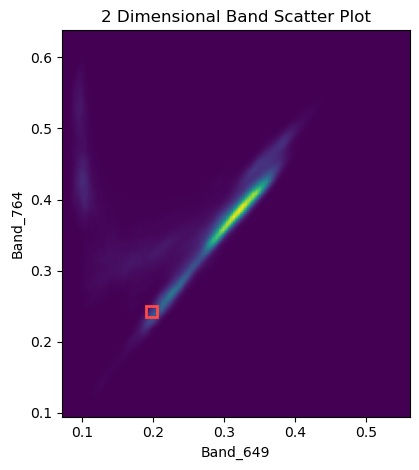

In [9]:
# Now, we're ready to plot some band combinations!
# We'll start out w/ Bands 649nm and 764nm
X_IDX = wavelength_map[min(wavelength_map, key=lambda w: abs(w - 649))]
Y_IDX = wavelength_map[min(wavelength_map, key=lambda w: abs(w - 764))]

# Ravel turns our 2D X-Y image array into a single dimensional array
band_x = image_arr[X_IDX].ravel()
band_y = image_arr[Y_IDX].ravel()

# Here we're filtering out our NaNs from the array. We use a single joint mask so that if a
# pixel is NaN in either band, it's dropped from both, keeping band_x and band_y aligned pixel-for-pixel.
valid = ~np.isnan(band_x) & ~np.isnan(band_y)
band_x = band_x[valid]
band_y = band_y[valid]

# This generates a two-dimensional histogram, or summary of our data statistics.
# It allows us to plot a "heatmap" of where points lie between two bands.
heatmap, xedges, yedges = np.histogram2d(band_x, band_y, bins=200)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# We then can plot our heatmap!
fig, ax = plt.subplots(1, 1)
ax.imshow(heatmap.T, extent=extent, origin="lower", cmap="viridis")
plt.xlabel(band_descriptions[X_IDX])
plt.ylabel(band_descriptions[Y_IDX])

# Since we highlighted where our selected pixel was on the image in the above spectral plot, let's
# also highlight where the pixel lies in our scatter plot!
box_size = (xedges[-1] - xedges[0]) * 0.03
pixel_rect = Rectangle(
    (pixel_spectra[X_IDX] - box_size / 2, pixel_spectra[Y_IDX] - box_size / 2),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="#ff4848",
    facecolor="none",
)
ax.add_patch(pixel_rect)

plt.title("2 Dimensional Band Scatter Plot")
plt.tight_layout()
plt.show()

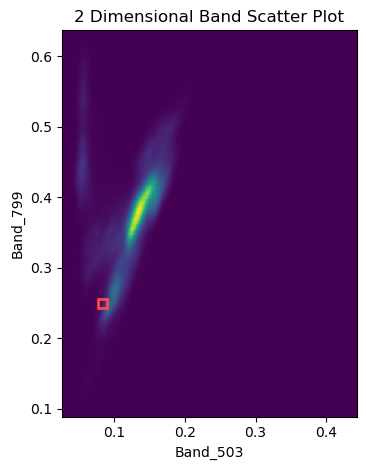

In [10]:
# Let's now do our first and last bands!
X_IDX = wavelength_map[min(wavelength_map, key=lambda w: abs(w - 503))]
Y_IDX = wavelength_map[min(wavelength_map, key=lambda w: abs(w - 799))]

# Ravel turns our 2D X-Y image array into a single dimensional array
band_x = image_arr[X_IDX].ravel()
band_y = image_arr[Y_IDX].ravel()

# Here we're filtering out our NaNs from the array. We use a single joint mask so that if a
# pixel is NaN in either band, it's dropped from both, keeping band_x and band_y aligned pixel-for-pixel.
valid = ~np.isnan(band_x) & ~np.isnan(band_y)
band_x = band_x[valid]
band_y = band_y[valid]

# This generates a two-dimensional histogram, or summary of our data statistics.
# It allows us to plot a "heatmap" of where points lie between two bands.
heatmap, xedges, yedges = np.histogram2d(band_x, band_y, bins=200)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# We then can plot our heatmap!
fig, ax = plt.subplots(1, 1)
ax.imshow(heatmap.T, extent=extent, origin="lower", cmap="viridis")
plt.xlabel(band_descriptions[X_IDX])
plt.ylabel(band_descriptions[Y_IDX])

# Since we highlighted where our selected pixel was on the image in the above spectral plot, let's
# also highlight where the pixel lies in our scatter plot!
box_size = (xedges[-1] - xedges[0]) * 0.03
pixel_rect = Rectangle(
    (pixel_spectra[X_IDX] - box_size / 2, pixel_spectra[Y_IDX] - box_size / 2),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="#ff4848",
    facecolor="none",
)
ax.add_patch(pixel_rect)

plt.title("2 Dimensional Band Scatter Plot")
plt.tight_layout()
plt.show()

As-generated these plots do not tell us much on their own. In both plots we can see a tight, bright cluster of pixels, this is the dirt/sand around the irrigated fields. The Y-axis in both plots represents a near-infrared band, while the X-axis represents a visible band. Vegetation generally has high near-infrared reflectance and lower visible reflectance, which produces the fainter diagonal spread of pixels extending away from that cluster toward higher Y (and lower X) values. We can see some distinct groups within that spread (feel free to zoom the plot in to this area!), these could correspond to different crop types, growth stages, or vegetation conditions. How cool!

We could extend these plots by highlighting areas of high-NDVI, or labeling areas with a shapefile and highlighting these areas to identify pixels that have a matching/similar spectra. We'll leave extending this notebook up to you, dear reader :)